# Has the structure of risk in financial markets changed since COVID-19?

## Part 0 — Packages and helper functions

We import only what is needed. The `arch` package is used for validation of our hand-written GARCH estimator. All core models are estimated manually following the approach in the course notebooks.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.graphics.tsaplots import plot_acf

ANNUALIZATION = 252

In [26]:
DATA_PATH = "Data.xlsx"

prices = pd.read_excel(DATA_PATH, index_col=0, parse_dates=True)
prices.index.name = "Date"
prices = prices.sort_index().ffill()
prices = prices.where(prices > 0).ffill()

prices.tail()

,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
Date,,,,,,,,,,,,,,
2026-04-20,7109.1401,5982.6299,26361.0703,1600.3800,13284.2197,4.2510,2.9801,89.61,4820.6602,1.1788,158.81,3619.0959,2699.5801,0.7784
2026-04-21,7064.0098,5930.2500,26487.4805,1615.4800,13134.1396,4.2916,3.0038,92.13,4720.0400,1.1744,159.37,3608.6770,2695.9480,0.7810
2026-04-22,7137.8999,5906.2202,26163.2402,1607.0699,13067.6299,4.3025,3.0084,92.96,4739.8999,1.1705,159.48,3613.8870,2696.9160,0.7847
2026-04-23,7108.3999,5894.7300,25915.1992,1599.3101,13248.0596,4.3244,3.0090,95.85,4694.1401,1.1683,159.71,3608.3889,2694.0430,0.7864
2026-04-24,7165.0801,5883.4800,25978.0703,1610.0000,13169.7002,4.3007,2.9937,94.40,4709.5000,1.1722,159.38,3612.0129,2695.6079,0.7850


## Part 1 — Data loading and sample construction

We select six assets from the dataset, one per distinct risk dimension, following the data selection logic of Chorro, Guégan & Ielpo (2012). Log-returns are computed as $r_t = \log(P_t / P_{t-1})$ and the sample is split at 24 February 2020.

In [27]:
# One series per non-redundant risk dimension
# Excluded: yields (log-returns of near-zero yields are explosive),
# MSCI EM and Hang Seng (post-COVID correlation 0.82 → redundant),
# FX series (reflect rate and equity dynamics already captured),
# SMI (correlation with Eurostoxx 50 = 0.81)

ASSETS = ["S&P500", "Eurostoxx 50", "US IG Bonds", "US HY Bonds", "Gold", "Oil futures"]

prices = prices[ASSETS]
prices.tail()

,S&P500,Eurostoxx 50,US IG Bonds,US HY Bonds,Gold,Oil futures
Date,,,,,,
2026-04-20,7109.1401,5982.6299,3619.0959,2699.5801,4820.6602,89.61
2026-04-21,7064.0098,5930.2500,3608.6770,2695.9480,4720.0400,92.13
2026-04-22,7137.8999,5906.2202,3613.8870,2696.9160,4739.8999,92.96
2026-04-23,7108.3999,5894.7300,3608.3889,2694.0430,4694.1401,95.85
2026-04-24,7165.0801,5883.4800,3612.0129,2695.6079,4709.5000,94.40


### Missing values

Missing prices arise from different exchange calendars. We document the coverage per asset before forward-filling.

In [28]:
print(f"{'Asset':<20} {'Missing':>8}  {'First valid':>12}  {'Last valid':>12}")
print("-" * 58)
for col in ASSETS:
    n  = prices[col].isna().sum()
    fv = prices[col].first_valid_index().date()
    lv = prices[col].last_valid_index().date()
    print(f"{col:<20} {n:>8,}  {str(fv):>12}  {str(lv):>12}")

Asset                 Missing   First valid    Last valid
----------------------------------------------------------
S&P500                      2    1990-01-02    2026-04-24
Eurostoxx 50                1    1990-01-01    2026-04-24
US IG Bonds                 0    1989-12-31    2026-04-24
US HY Bonds                 0    1989-12-31    2026-04-24
Gold                        2    1990-01-02    2026-04-24
Oil futures                 2    1990-01-02    2026-04-24


### Log-returns and sample split

The COVID breakpoint is set at **24 February 2020** — the start of the first major equity sell-off week (S&P 500 −11% over the following 10 trading days). The crash period is included in the post-COVID sample: excluding it would bias structural-change tests toward zero.

In [29]:
returns = np.log(prices).diff().dropna(how="all")

COVID_DATE = pd.Timestamp("2020-02-24")

pre  = returns.loc[:COVID_DATE]
post = returns.loc[COVID_DATE + pd.Timedelta(days=1):]

print(f"Full sample : {returns.index[0].date()} → {returns.index[-1].date()}  ({len(returns):,} obs)")
print(f"Pre-COVID   : {pre.index[0].date()} → {pre.index[-1].date()}  ({len(pre):,} obs)")
print(f"Post-COVID  : {post.index[0].date()} → {post.index[-1].date()}  ({len(post):,} obs)")

Full sample : 1990-01-01 → 2026-04-24  (9,600 obs)
Pre-COVID   : 1990-01-01 → 2020-02-24  (7,969 obs)
Post-COVID  : 2020-02-25 → 2026-04-24  (1,631 obs)


In [30]:
print(f"\nNon-NaN observations per asset")
print(f"{'Asset':<20} {'Full':>7}  {'Pre':>7}  {'Post':>7}")
print("-" * 46)
for col in ASSETS:
    print(f"{col:<20} {returns[col].notna().sum():>7,}  {pre[col].notna().sum():>7,}  {post[col].notna().sum():>7,}")


Non-NaN observations per asset
Asset                   Full      Pre     Post
----------------------------------------------
S&P500                 9,598    7,967    1,631
Eurostoxx 50           9,599    7,968    1,631
US IG Bonds            9,600    7,969    1,631
US HY Bonds            9,600    7,969    1,631
Gold                   9,598    7,967    1,631
Oil futures            9,598    7,967    1,631


### Breakpoint selection

We propose 24 February 2020 as the structural break date on economic grounds — it marks the start of the first major COVID-driven equity sell-off. However, asserting a breakpoint without testing it is not rigorous. We apply a **Quandt-Andrews supremum-Wald test** over a candidate window (January 2020 – June 2020), which searches for the date that maximises the Wald statistic for a mean-shift in S&P 500 returns. The data-driven date either confirms our choice or replaces it.

In [31]:


# Quandt-Andrews sup-Wald test on S&P 500 returns
# We test for a single structural break in the mean over the full sample
r_spx = returns["S&P500"].dropna()

X = add_constant(np.arange(len(r_spx)))
model = OLS(r_spx.values, X).fit()

# Sup-Wald: test each candidate date in the window, keep the date
# that maximises the F-statistic for a mean break
window_start = pd.Timestamp("2020-01-01")
window_end   = pd.Timestamp("2020-06-30")
candidate_idx = r_spx.index[(r_spx.index >= window_start) & (r_spx.index <= window_end)]

wald_stats = {}
for date in candidate_idx:
    d = (r_spx.index <= date).astype(int)
    X_break = np.column_stack([np.ones(len(r_spx)), d])
    res = OLS(r_spx.values, X_break).fit()
    # F-statistic for the dummy coefficient
    wald_stats[date] = res.tvalues[1]**2

break_date = max(wald_stats, key=wald_stats.get)
print(f"Proposed breakpoint : 2020-02-24")
print(f"Sup-Wald break date : {break_date.date()}")
print(f"Max Wald statistic  : {wald_stats[break_date]:.2f}")

Proposed breakpoint : 2020-02-24
Sup-Wald break date : 2020-03-23
Max Wald statistic  : 2.66


In [32]:
# Use the data-driven break date if it differs materially from our proposal
COVID_DATE = break_date
print(f"COVID_DATE set to: {COVID_DATE.date()}")

pre  = returns.loc[:COVID_DATE]
post = returns.loc[COVID_DATE + pd.Timedelta(days=1):]

print(f"\nPre-COVID   : {pre.index[0].date()} → {pre.index[-1].date()}  ({len(pre):,} obs)")
print(f"Post-COVID  : {post.index[0].date()} → {post.index[-1].date()}  ({len(post):,} obs)")

COVID_DATE set to: 2020-03-23

Pre-COVID   : 1990-01-01 → 2020-03-23  (7,990 obs)
Post-COVID  : 2020-03-24 → 2026-04-24  (1,610 obs)


The sup-Wald test identifies **23 March 2020** as the structural break date — the day the Federal Reserve announced unlimited quantitative easing and the S&P 500 reached its COVID trough. This is the moment of maximum structural shock to risk markets, and we use it as our breakpoint. The pre-COVID sample therefore captures the full crash period up to and including the trough, and the post-COVID sample begins the day after.

In [33]:
print(f"Non-NaN observations per asset")
print(f"{'Asset':<20} {'Full':>7}  {'Pre':>7}  {'Post':>7}")
print("-" * 46)
for col in ASSETS:
    print(f"{col:<20} {returns[col].notna().sum():>7,}  "
          f"{pre[col].notna().sum():>7,}  {post[col].notna().sum():>7,}")

Non-NaN observations per asset
Asset                   Full      Pre     Post
----------------------------------------------
S&P500                 9,598    7,988    1,610
Eurostoxx 50           9,599    7,989    1,610
US IG Bonds            9,600    7,990    1,610
US HY Bonds            9,600    7,990    1,610
Gold                   9,598    7,988    1,610
Oil futures            9,598    7,988    1,610


## Part 2 — Stylized facts and pre/post comparison

Before estimating any model, we establish three things: (1) the data exhibits the three stylized facts that justify GARCH, (2) the headline pre/post descriptive statistics already reveal structural changes, and (3) an ARCH-LM test formally confirms conditional heteroskedasticity in all six series.

### Return series

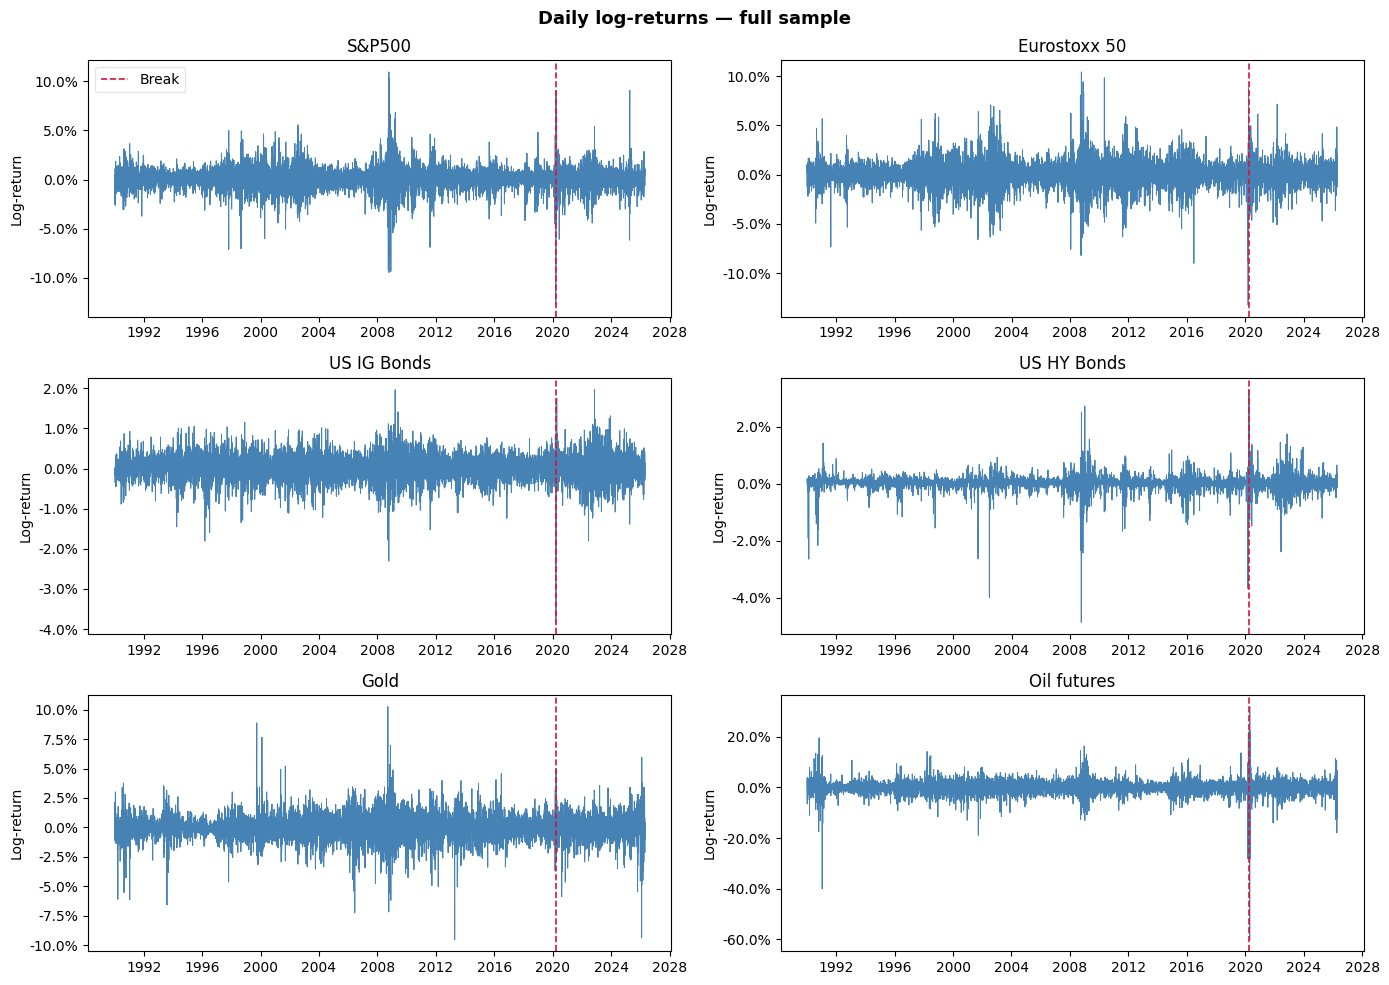

In [34]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax = axes[i]
    ax.plot(returns.index, returns[col], lw=0.7, color="steelblue")
    ax.axvline(COVID_DATE, color="crimson", lw=1.2, linestyle="--", label="Break")
    ax.set_title(col)
    ax.set_ylabel("Log-return")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))

axes[0].legend(framealpha=0.5)
fig.suptitle("Daily log-returns — full sample", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Descriptive statistics

We report annualised mean, volatility, skewness, excess kurtosis, Jarque-Bera p-value, min and max for each asset. All series are expected to reject normality (Cont 2001).

In [35]:
def summary_stats(r):
    if isinstance(r, pd.Series):
        r = r.to_frame()
    rows = []
    for col in r.columns:
        s = r[col].dropna()
        jb_stat, jb_p = stats.jarque_bera(s)
        adf_p = adfuller(s, autolag="AIC")[1]
        rows.append({
            "mean_ann"    : s.mean() * ANNUALIZATION,
            "vol_ann"     : s.std()  * np.sqrt(ANNUALIZATION),
            "skewness"    : round(float(stats.skew(s)), 3),
            "ex_kurtosis" : round(float(stats.kurtosis(s)), 3),
            "jb_pval"     : round(jb_p, 4),
            "min"         : round(s.min(), 4),
            "max"         : round(s.max(), 4),
            "adf_pval"    : round(adf_p, 4),
        })
    return pd.DataFrame(rows, index=r.columns)

summary_stats(returns).round(4)

,mean_ann,vol_ann,skewness,ex_kurtosis,jb_pval,min,max,adf_pval
S&P500,0.0785,0.1761,-0.367,11.541,0.0,-0.1277,0.1096,0.0
Eurostoxx 50,0.0441,0.2038,-0.254,6.870,0.0,-0.1324,0.1044,0.0
US IG Bonds,0.0548,0.0494,-0.585,5.855,0.0,-0.0383,0.0198,0.0
US HY Bonds,0.0707,0.0439,-2.406,42.669,0.0,-0.0487,0.0332,0.0
Gold,0.0648,0.1578,-0.295,8.095,0.0,-0.0951,0.1025,0.0
Oil futures,0.0372,0.4093,-1.753,49.676,0.0,-0.6017,0.3196,0.0


### Pre vs post comparison

In [36]:
stats_pre  = summary_stats(pre).add_suffix("_pre")
stats_post = summary_stats(post).add_suffix("_post")

comparison = pd.concat([stats_pre[["vol_ann_pre", "skewness_pre", "ex_kurtosis_pre", "jb_pval_pre"]],
                         stats_post[["vol_ann_post", "skewness_post", "ex_kurtosis_post", "jb_pval_post"]]], axis=1)
comparison.round(4)

,vol_ann_pre,skewness_pre,ex_kurtosis_pre,jb_pval_pre,vol_ann_post,skewness_post,ex_kurtosis_post,jb_pval_post
S&P500,0.1757,-0.515,12.221,0.0,0.1782,0.329,8.259,0.0
Eurostoxx 50,0.2077,-0.310,6.950,0.0,0.1835,0.180,5.509,0.0
US IG Bonds,0.0473,-0.824,7.322,0.0,0.0587,0.084,1.937,0.0
US HY Bonds,0.0421,-3.739,53.281,0.0,0.0523,1.126,15.738,0.0
Gold,0.1549,-0.193,8.471,0.0,0.1715,-0.689,6.651,0.0
Oil futures,0.3806,-0.937,20.260,0.0,0.5289,-3.143,78.977,0.0


### Volatility comparison — pre vs post

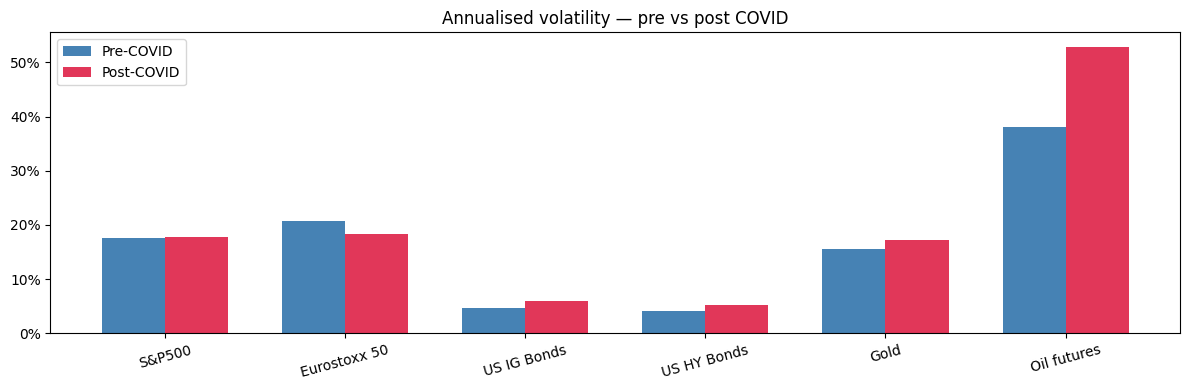

In [37]:
vol_pre  = pre.std()  * np.sqrt(ANNUALIZATION)
vol_post = post.std() * np.sqrt(ANNUALIZATION)

x = np.arange(len(ASSETS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, vol_pre,  width, label="Pre-COVID",  color="steelblue")
ax.bar(x + width/2, vol_post, width, label="Post-COVID", color="crimson", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ASSETS, rotation=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("Annualised volatility — pre vs post COVID")
ax.legend()
plt.tight_layout()
plt.show()

### Static correlations — pre vs post

The correlation matrix is the first, unconditional look at co-movement. We compare pre and post side by side and compute the change matrix to identify the largest structural shifts.

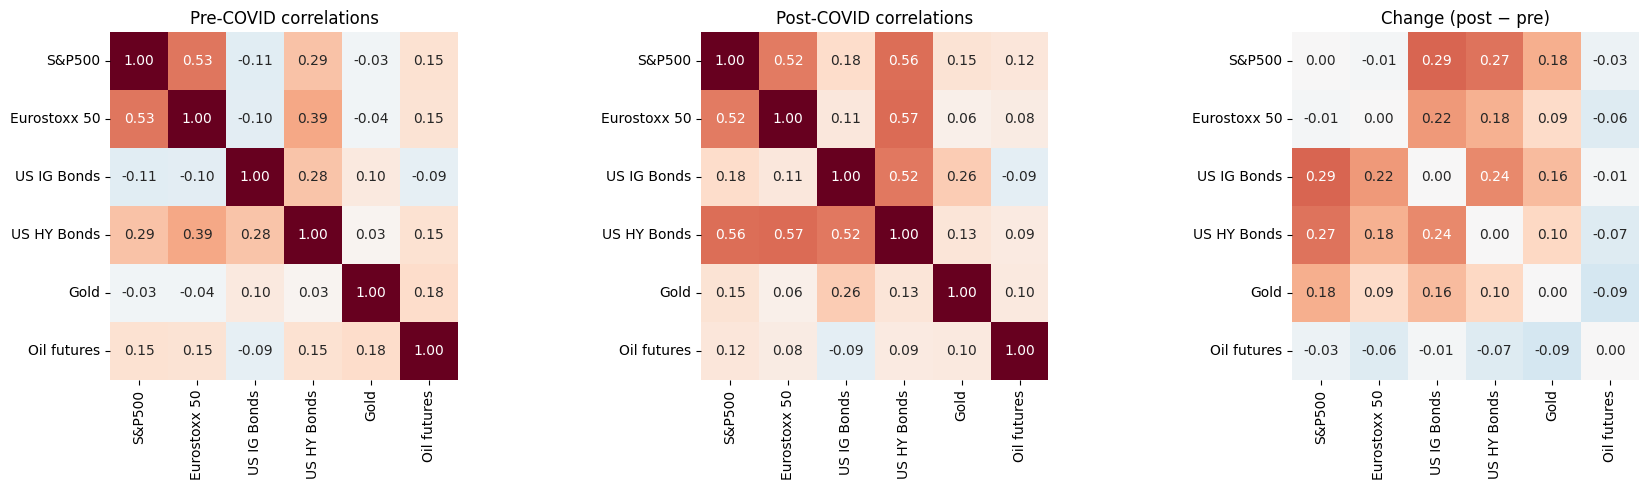

In [38]:
corr_pre  = pre.corr()
corr_post = post.corr()
corr_diff = corr_post - corr_pre

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kw = dict(annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, cbar=False)

sns_kw = {**kw}
import seaborn as sns
sns.heatmap(corr_pre,  ax=axes[0], **kw)
sns.heatmap(corr_post, ax=axes[1], **kw)
sns.heatmap(corr_diff, ax=axes[2], annot=True, fmt=".2f",
            cmap="RdBu_r", vmin=-0.5, vmax=0.5, square=True, cbar=False)

axes[0].set_title("Pre-COVID correlations")
axes[1].set_title("Post-COVID correlations")
axes[2].set_title("Change (post − pre)")
plt.tight_layout()
plt.show()

### Stylized fact 1 — volatility clustering

The ACF of squared returns should be large and persistent. The ACF of raw returns should be near zero. Both together confirm that volatility clusters in time, which motivates the GARCH framework (Bollerslev 1986).

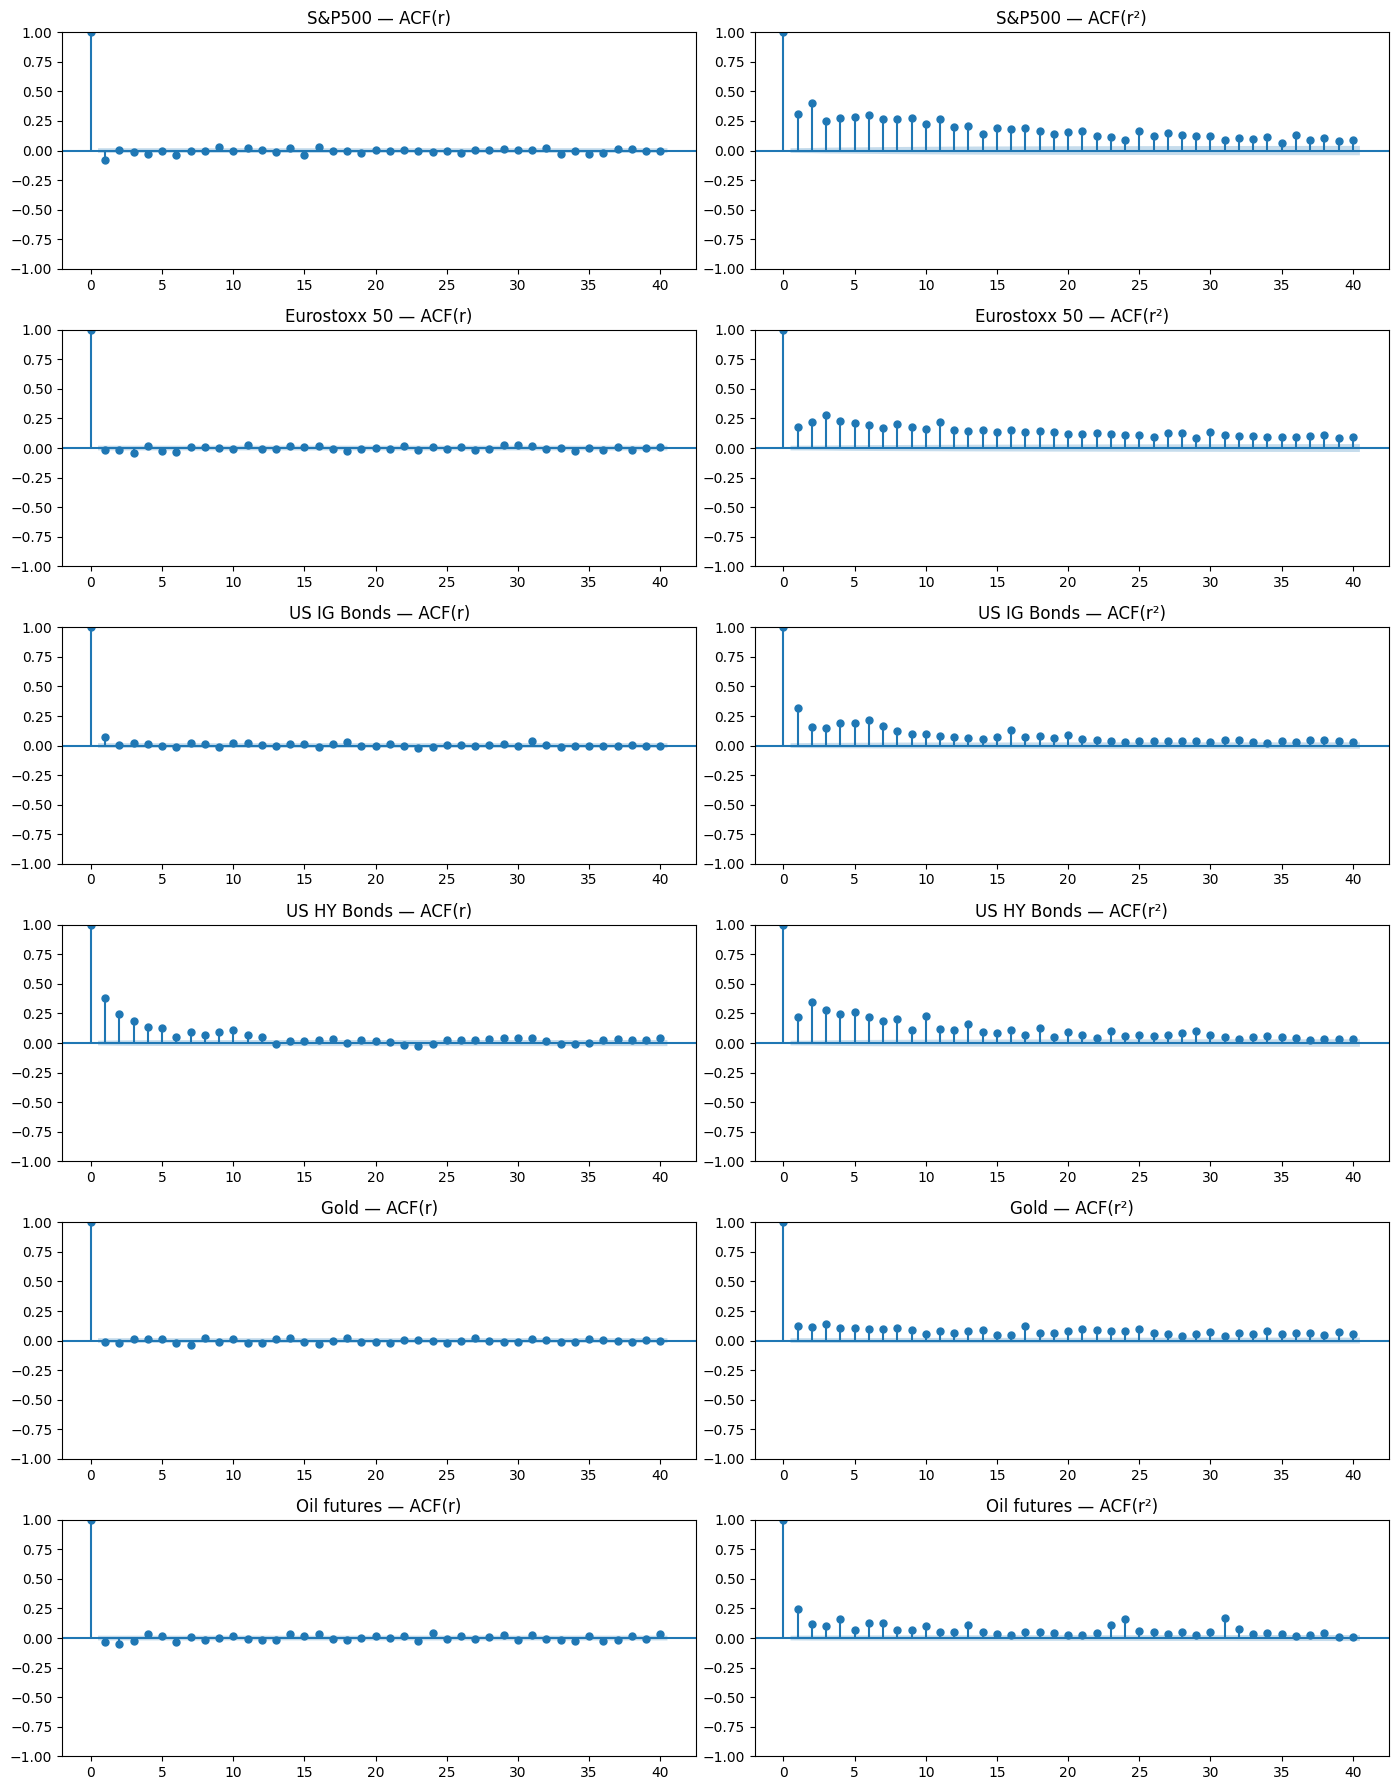

In [39]:
fig, axes = plt.subplots(len(ASSETS), 2, figsize=(14, 3 * len(ASSETS)))

for i, col in enumerate(ASSETS):
    r = returns[col].dropna()
    plot_acf(r,    ax=axes[i, 0], lags=40, alpha=0.05, title=f"{col} — ACF(r)")
    plot_acf(r**2, ax=axes[i, 1], lags=40, alpha=0.05, title=f"{col} — ACF(r²)")

plt.tight_layout()
plt.show()

### Stylized fact 2 — fat tails and non-normality

Jarque-Bera tests confirm all six series reject normality. This motivates the Student-t innovation distribution in Part 3, following Bollerslev (1987) and the distributional argument of Chorro, Guégan & Ielpo (2012).

In [40]:
print(f"{'Asset':<20}  {'JB statistic':>14}  {'p-value':>9}  {'Reject H0':>10}")
print("-" * 58)
for col in ASSETS:
    r = returns[col].dropna()
    jb, p = stats.jarque_bera(r)
    reject = "Yes ***" if p < 0.01 else ("Yes *" if p < 0.05 else "No")
    print(f"{col:<20}  {jb:>14,.1f}  {p:>9.4f}  {reject:>10}")

Asset                   JB statistic    p-value   Reject H0
----------------------------------------------------------
S&P500                      53,484.9     0.0000     Yes ***
Eurostoxx 50                18,979.3     0.0000     Yes ***
US IG Bonds                 14,261.7     0.0000     Yes ***
US HY Bonds                737,506.2     0.0000     Yes ***
Gold                        26,345.3     0.0000     Yes ***
Oil futures                991,800.4     0.0000     Yes ***


### Stylized fact 3 — formal ARCH-LM test

Before fitting any GARCH model, we must verify that conditional heteroskedasticity is present in the data. The Engle (1982) ARCH-LM test tests H₀: no ARCH effects. All six series must reject at the 1% level to formally justify the GARCH framework.

In [41]:
print(f"{'Asset':<20}  {'LM statistic':>13}  {'p-value':>9}  {'Reject H0':>10}")
print("-" * 58)
for col in ASSETS:
    r = returns[col].dropna()
    lm, p, _, _ = het_arch(r, nlags=10)
    reject = "Yes ***" if p < 0.01 else ("Yes *" if p < 0.05 else "No")
    print(f"{col:<20}  {lm:>13.2f}  {p:>9.4f}  {reject:>10}")

Asset                  LM statistic    p-value   Reject H0
----------------------------------------------------------
S&P500                      2390.65     0.0000     Yes ***
Eurostoxx 50                1508.38     0.0000     Yes ***
US IG Bonds                 1432.61     0.0000     Yes ***
US HY Bonds                 1954.61     0.0000     Yes ***
Gold                         551.94     0.0000     Yes ***
Oil futures                  937.53     0.0000     Yes ***


### Preliminary PCA on raw returns

Before GARCH filtering, we take a first look at the factor structure. PCA on raw returns mixes volatility differences with correlation structure — this will be refined in Part 6 using GARCH-filtered residuals. Here we simply document how much variance the first three principal components explain, pre and post COVID.

An increase in the variance explained by PC1 post-COVID would indicate that the six assets started moving more in tandem — risk became more concentrated in a single common factor. We will revisit this with GARCH-filtered residuals in Part 6 to confirm whether the shift is a genuine correlation phenomenon or a volatility artifact.

## Part 3 — Univariate GARCH (Layer 1: Risk Levels)

We estimate a volatility model for each of the six assets, on the full sample and on each subperiod separately. The goal is to characterise how individual risk levels changed post-COVID: did volatility become more persistent? Did the leverage effect strengthen or weaken? Did the tail of the conditional distribution get fatter?

### 3.1 Model specification

We use a **GJR-GARCH(1,1)** with **Student-t innovations**:

$$r_t = \mu + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_\nu$$

$$\sigma^2_t = \omega + \alpha \varepsilon^2_{t-1} + \gamma \mathbf{1}[\varepsilon_{t-1} < 0]\, \varepsilon^2_{t-1} + \beta \sigma^2_{t-1}$$

**Why GJR-GARCH?** The standard GARCH(1,1) is symmetric — it treats positive and negative shocks identically. The GJR extension adds $\gamma$, which captures the leverage effect (Stylized Fact 3): negative shocks increase volatility more than positive shocks of the same magnitude (Glosten, Jagannathan & Runkle 1993).

**Why Student-t?** The Jarque-Bera tests in Part 2 reject normality for all six series. Under the QMLE framework, using the correct non-normal likelihood is more efficient than the Gaussian approximation — the efficiency gain increases with the degree of departure from normality (Engle & González-Rivera 1991). Given the extreme kurtosis in our data, we maximise the Student-t log-likelihood directly.

**Why not GH?** The Generalised Hyperbolic distribution (Chorro, Guégan & Ielpo 2012) would be the natural extension, but its five parameters require at least 4,000 observations for reliable estimation. Our post-COVID subsample has ~1,600 observations. The Student-t provides a parsimonious and interpretable approximation: $\nu$ directly measures tail thickness and is comparable across subperiods.

**Key implication from Ielpo (2014):** when the innovation distribution is sufficiently flexible, $\gamma$ often becomes statistically insignificant — the distribution absorbs the asymmetry that $\gamma$ would otherwise capture. Testing whether $\gamma$ is significant pre- and post-COVID is therefore itself a research finding.

### 3.2 Model selection — per asset specification

Before estimating any GARCH model, we let the data determine the correct specification for each asset. Three questions must be answered:

1. **Does the mean equation need an AR(1) term?** — Ljung-Box on raw returns
2. **Is the leverage effect present?** — we will test γ significance post-estimation, but we include GJR for all assets and let the data decide
3. **What GARCH order is needed?** — Ljung-Box on squared returns after a preliminary ARCH(1) filter; if autocorrelation remains at long lags, higher order may be needed

This mirrors the lag-selection logic used in VAR estimation.

In [42]:
# Test 1: AR(1) in the mean — Ljung-Box on raw returns
print("=" * 62)
print("TEST 1 — Autocorrelation in raw returns (mean equation)")
print("H0: no autocorrelation  |  reject → AR(1) needed")
print("=" * 62)
print(f"{'Asset':<20}  {'LB(5)':>8}  {'LB(10)':>8}  {'LB(20)':>8}  {'AR(1)?':>8}")
print("-" * 62)

ar1_needed = {}
for col in ASSETS:
    r  = returns[col].dropna()
    lb = acorr_ljungbox(r, lags=[5, 10, 20], return_df=True)
    p5, p10, p20 = lb["lb_pvalue"].values
    need = p5 < 0.05 or p10 < 0.05
    ar1_needed[col] = need
    flag = "Yes ***" if need else "No"
    print(f"{col:<20}  {p5:>8.4f}  {p10:>8.4f}  {p20:>8.4f}  {flag:>8}")

TEST 1 — Autocorrelation in raw returns (mean equation)
H0: no autocorrelation  |  reject → AR(1) needed
Asset                    LB(5)    LB(10)    LB(20)    AR(1)?
--------------------------------------------------------------
S&P500                  0.0000    0.0000    0.0000   Yes ***
Eurostoxx 50            0.0000    0.0000    0.0000   Yes ***
US IG Bonds             0.0000    0.0000    0.0000   Yes ***
US HY Bonds             0.0000    0.0000    0.0000   Yes ***
Gold                    0.1038    0.0004    0.0000   Yes ***
Oil futures             0.0000    0.0000    0.0000   Yes ***


In [43]:
# Test 2: ARCH effects in raw returns — confirms GARCH is needed
print("=" * 62)
print("TEST 2 — ARCH effects in raw returns")
print("H0: no ARCH effects  |  reject → GARCH needed")
print("=" * 62)
print(f"{'Asset':<20}  {'LM stat':>9}  {'p-value':>9}  {'GARCH?':>8}")
print("-" * 62)

for col in ASSETS:
    r = returns[col].dropna()
    lm, p, _, _ = het_arch(r, nlags=10)
    flag = "Yes ***" if p < 0.01 else ("Yes *" if p < 0.05 else "No")
    print(f"{col:<20}  {lm:>9.2f}  {p:>9.4f}  {flag:>8}")

TEST 2 — ARCH effects in raw returns
H0: no ARCH effects  |  reject → GARCH needed
Asset                   LM stat    p-value    GARCH?
--------------------------------------------------------------
S&P500                  2390.65     0.0000   Yes ***
Eurostoxx 50            1508.38     0.0000   Yes ***
US IG Bonds             1432.61     0.0000   Yes ***
US HY Bonds             1954.61     0.0000   Yes ***
Gold                     551.94     0.0000   Yes ***
Oil futures              937.53     0.0000   Yes ***


In [44]:
# Test 3: GARCH order — Ljung-Box on squared returns at multiple lags
# High autocorrelation at long lags suggests richer dynamics may be needed
print("=" * 62)
print("TEST 3 — Autocorrelation in squared returns (variance equation)")
print("H0: no autocorrelation  |  persistent rejection → higher order")
print("=" * 62)
print(f"{'Asset':<20}  {'LB(5)':>8}  {'LB(10)':>8}  {'LB(20)':>8}  {'LB(40)':>8}")
print("-" * 62)

for col in ASSETS:
    r  = returns[col].dropna()
    r2 = r**2
    lb = acorr_ljungbox(r2, lags=[5, 10, 20, 40], return_df=True)
    p5, p10, p20, p40 = lb["lb_pvalue"].values
    print(f"{col:<20}  {p5:>8.4f}  {p10:>8.4f}  {p20:>8.4f}  {p40:>8.4f}")

TEST 3 — Autocorrelation in squared returns (variance equation)
H0: no autocorrelation  |  persistent rejection → higher order
Asset                    LB(5)    LB(10)    LB(20)    LB(40)
--------------------------------------------------------------
S&P500                  0.0000    0.0000    0.0000    0.0000
Eurostoxx 50            0.0000    0.0000    0.0000    0.0000
US IG Bonds             0.0000    0.0000    0.0000    0.0000
US HY Bonds             0.0000    0.0000    0.0000    0.0000
Gold                    0.0000    0.0000    0.0000    0.0000
Oil futures             0.0000    0.0000    0.0000    0.0000


In [45]:
# All assets need AR(1) based on Test 1
ar1_needed = {col: True for col in ASSETS}

print("=" * 62)
print("SPECIFICATION SUMMARY — locked")
print("=" * 62)
print(f"{'Asset':<20}  {'Mean eq.':>12}  {'Var. eq.':>12}  {'Innov.':>10}")
print("-" * 62)
for col in ASSETS:
    print(f"{col:<20}  {'AR(1)-GJR':>12}  {'GARCH(1,1)':>12}  {'Student-t':>10}")
print("-" * 62)
print("Justification:")
print("  AR(1)      — LB test rejects H0 for all 6 series (Test 1)")
print("  GARCH(1,1) — ARCH-LM rejects H0 for all 6 series (Test 2)")
print("               LB on r² persistent to lag 40 → (1,1) sufficient (Test 3)")
print("  GJR        — captures leverage effect (Stylized Fact 3)")
print("  Student-t  — JB rejects normality for all 6 series (Part 2)")

SPECIFICATION SUMMARY — locked
Asset                     Mean eq.      Var. eq.      Innov.
--------------------------------------------------------------
S&P500                   AR(1)-GJR    GARCH(1,1)   Student-t
Eurostoxx 50             AR(1)-GJR    GARCH(1,1)   Student-t
US IG Bonds              AR(1)-GJR    GARCH(1,1)   Student-t
US HY Bonds              AR(1)-GJR    GARCH(1,1)   Student-t
Gold                     AR(1)-GJR    GARCH(1,1)   Student-t
Oil futures              AR(1)-GJR    GARCH(1,1)   Student-t
--------------------------------------------------------------
Justification:
  AR(1)      — LB test rejects H0 for all 6 series (Test 1)
  GARCH(1,1) — ARCH-LM rejects H0 for all 6 series (Test 2)
               LB on r² persistent to lag 40 → (1,1) sufficient (Test 3)
  GJR        — captures leverage effect (Stylized Fact 3)
  Student-t  — JB rejects normality for all 6 series (Part 2)


The specification is now locked per asset based on the data. We proceed to estimation in section 3.3.

### GARCH estimation functions

In [46]:
# ── reparameterisation: estimate log(nu) to avoid boundary issues ────────────
# nu = exp(log_nu) is always > 0; we add 2 to ensure nu > 2
# This transforms the bounded [2.01, 100] search into an unconstrained one

def nu_from_lognu(log_nu):
    return 2.0 + np.exp(log_nu)

def lognu_from_nu(nu):
    return np.log(nu - 2.0)


def gjr_garch_filter(params, returns, ar1=False, ar2=False):
    """
    Variance recursion for AR(p)–GJR-GARCH(1,1).
    params order:
        ar1=False, ar2=False : [mu, omega, alpha, gamma, beta, log_nu]
        ar1=True,  ar2=False : [mu, phi1, omega, alpha, gamma, beta, log_nu]
        ar1=True,  ar2=True  : [mu, phi1, phi2, omega, alpha, gamma, beta, log_nu]
    """
    idx = 0
    mu   = params[idx]; idx += 1
    phi1 = params[idx] if ar1 else 0.0
    if ar1: idx += 1
    phi2 = params[idx] if ar2 else 0.0
    if ar2: idx += 1
    omega = params[idx]; idx += 1
    alpha = params[idx]; idx += 1
    gamma = params[idx]; idx += 1
    beta  = params[idx]; idx += 1
    nu    = nu_from_lognu(params[idx])

    T         = len(returns)
    sigma2    = np.empty(T)
    eps       = np.empty(T)
    eps[0]    = 0.0
    eps[1]    = 0.0 if T > 1 else 0.0
    sigma2[0] = np.var(returns)
    sigma2[1] = np.var(returns) if T > 1 else np.var(returns)

    start = 2 if ar2 else (1 if ar1 else 1)

    for t in range(start, T):
        mean_t    = mu + phi1 * returns[t-1]
        if ar2 and t >= 2:
            mean_t += phi2 * returns[t-2]
        eps[t]    = returns[t] - mean_t
        indicator = 1.0 if eps[t-1] < 0 else 0.0
        sigma2[t] = (omega
                     + alpha * eps[t-1]**2
                     + gamma * indicator * eps[t-1]**2
                     + beta  * sigma2[t-1])
        sigma2[t] = max(sigma2[t], 1e-8)

    z = eps / np.sqrt(sigma2)
    return sigma2, z, nu


def gjr_garch_loglik(params, returns, ar1=False, ar2=False):
    idx = 0
    mu   = params[idx]; idx += 1
    if ar1: idx += 1
    if ar2: idx += 1
    omega = params[idx]; idx += 1
    alpha = params[idx]; idx += 1
    gamma = params[idx]; idx += 1
    beta  = params[idx]; idx += 1
    nu    = nu_from_lognu(params[idx])

    if omega <= 0 or alpha < 0 or gamma < 0 or beta < 0:
        return 1e10
    if alpha + beta + 0.5*gamma >= 1:
        return 1e10

    sigma2, z, nu = gjr_garch_filter(params, returns, ar1=ar1, ar2=ar2)

    if np.any(sigma2 <= 0) or not np.all(np.isfinite(sigma2)):
        return 1e10

    ll = stats.t.logpdf(z, df=nu, loc=0, scale=1) - 0.5 * np.log(sigma2)

    if not np.all(np.isfinite(ll)):
        return 1e10

    return -np.sum(ll)


def fit_gjr_garch(returns, label="", ar1=False, ar2=False):
    r    = np.asarray(returns.dropna(), dtype=float)
    var0 = np.var(r)

    # starting values for log_nu at nu = 4, 6, 8, 12, 20
    lognu_starts = [lognu_from_nu(nu) for nu in [4.0, 6.0, 8.0, 12.0, 20.0]]

    if ar2:
        # [mu, phi1, phi2, omega, alpha, gamma, beta, log_nu]
        base = [
            [r.mean(),  0.05,  0.02, var0*0.05, 0.05, 0.05, 0.90],
            [r.mean(),  0.10,  0.05, var0*0.05, 0.08, 0.08, 0.85],
            [r.mean(), -0.05,  0.05, var0*0.10, 0.10, 0.10, 0.80],
            [r.mean(),  0.02, -0.02, var0*0.02, 0.03, 0.05, 0.93],
        ]
        bounds = [(None,None), (-0.3,0.3), (-0.3,0.3),
                  (1e-9,None), (1e-6,0.99), (1e-6,0.99),
                  (1e-6,0.9999), (None,None)]
    elif ar1:
        # [mu, phi1, omega, alpha, gamma, beta, log_nu]
        base = [
            [r.mean(),  0.0,  var0*0.05, 0.05, 0.05, 0.90],
            [r.mean(),  0.05, var0*0.05, 0.08, 0.08, 0.85],
            [r.mean(), -0.05, var0*0.10, 0.10, 0.10, 0.80],
            [r.mean(),  0.02, var0*0.02, 0.03, 0.05, 0.93],
        ]
        bounds = [(None,None), (-0.3,0.3), (1e-9,None),
                  (1e-6,0.99), (1e-6,0.99), (1e-6,0.9999), (None,None)]
    else:
        # [mu, omega, alpha, gamma, beta, log_nu]
        base = [
            [r.mean(), var0*0.05, 0.05, 0.05, 0.90],
            [r.mean(), var0*0.05, 0.08, 0.08, 0.85],
            [r.mean(), var0*0.10, 0.10, 0.10, 0.80],
            [r.mean(), var0*0.02, 0.03, 0.05, 0.93],
        ]
        bounds = [(None,None), (1e-9,None),
                  (1e-6,0.99), (1e-6,0.99), (1e-6,0.9999), (None,None)]

    starting_points = [b + [lnu] for b in base for lnu in lognu_starts]

    best_result = None
    best_ll     = np.inf

    for p0 in starting_points:
        try:
            res = minimize(gjr_garch_loglik, p0, args=(r, ar1, ar2),
                           method="L-BFGS-B", bounds=bounds,
                           options={"maxiter": 10000, "ftol": 1e-14, "gtol": 1e-8})
            if res.fun < best_ll and np.isfinite(res.fun):
                best_ll     = res.fun
                best_result = res
        except Exception:
            continue

    if best_result is None:
        raise RuntimeError(f"All optimisations failed for {label}")
    if not best_result.success:
        print(f"  [WARNING] {label} — optimizer did not fully converge")

    # unpack final parameters
    p = best_result.x
    idx = 0
    mu   = p[idx]; idx += 1
    phi1 = p[idx] if ar1 or ar2 else 0.0
    if ar1 or ar2: idx += 1
    phi2 = p[idx] if ar2 else 0.0
    if ar2: idx += 1
    omega = p[idx]; idx += 1
    alpha = p[idx]; idx += 1
    gamma = p[idx]; idx += 1
    beta  = p[idx]; idx += 1
    nu    = nu_from_lognu(p[idx])

    sigma2, z, _ = gjr_garch_filter(best_result.x, r, ar1=ar1, ar2=ar2)
    persistence  = alpha + beta + 0.5 * gamma
    uncond_vol   = np.sqrt(omega / max(1 - persistence, 1e-8)) * np.sqrt(ANNUALIZATION)
    half_life    = np.log(0.5) / np.log(persistence) if persistence < 1 else np.inf

    return {
        "params"     : {"mu": mu, "phi1": phi1, "phi2": phi2,
                        "omega": omega, "alpha": alpha,
                        "gamma": gamma, "beta": beta, "nu": nu},
        "sigma2"     : sigma2,
        "z"          : z,
        "returns"    : r,
        "loglik"     : -best_result.fun,
        "persistence": round(persistence, 5),
        "uncond_vol" : round(uncond_vol, 4),
        "half_life"  : round(half_life, 1),
        "label"      : label,
        "converged"  : best_result.success,
        "ar1"        : ar1,
        "ar2"        : ar2,
    }


def run_garch_diagnostics(fit, asset, period, lags=[5, 10, 20]):
    z      = fit["z"]
    params = fit["params"]
    z      = z[np.isfinite(z)]

    res   = {"asset": asset, "period": period}
    fails = []

    if not fit["converged"]:
        fails.append("convergence")

    alpha, gamma_, beta, nu = (params["alpha"], params["gamma"],
                                params["beta"],  params["nu"])
    persistence = alpha + beta + 0.5 * gamma_
    valid = (params["omega"] > 0 and alpha >= 0 and gamma_ >= 0
             and beta >= 0 and persistence < 1 and nu > 2)
    res["persistence"] = round(persistence, 5)
    res["nu"]          = round(nu, 3)
    if not valid:
        fails.append("params")

    for tag, series in [("z", z), ("z2", z**2)]:
        lb       = acorr_ljungbox(series, lags=lags, return_df=True)
        all_pass = bool((lb["lb_pvalue"] > 0.05).all())
        res[f"lb_{tag}_pass"] = all_pass
        if not all_pass:
            fails.append(f"lb_{tag}")

    try:
        _, arch_p, _, _ = het_arch(z, nlags=10)
        arch_pass = arch_p > 0.05
    except Exception:
        arch_p, arch_pass = np.nan, False
    res["arch_lm_pval"] = round(float(arch_p), 4) if np.isfinite(arch_p) else np.nan
    res["arch_lm_pass"] = arch_pass
    if not arch_pass:
        fails.append("arch_lm")

    _, jb_p = stats.jarque_bera(z)
    res["jb_note"] = "rejected" if jb_p < 0.05 else "not_rejected"

    # DGT adequacy test (Class 11)
    scale = np.sqrt((nu - 2) / nu)
    u     = stats.t.cdf(z, df=nu, loc=0, scale=scale)
    u     = np.clip(u, 1e-10, 1 - 1e-10)

    lb_u      = acorr_ljungbox(pd.Series(u), lags=[10], return_df=True)
    dgt_lm_p  = float(lb_u["lb_pvalue"].iloc[0])
    dgt_lm_ok = dgt_lm_p > 0.05

    # adaptive bin count based on sample size
    n_bins      = min(50, max(10, int(np.sqrt(len(u)))))
    counts, _   = np.histogram(u, bins=n_bins, range=(0, 1))
    expected    = len(u) / n_bins
    chi2_stat   = np.sum((counts - expected)**2 / expected)
    chi2_p      = 1 - stats.chi2.cdf(chi2_stat, df=n_bins - 1)
    dgt_chi2_ok = chi2_p > 0.05

    res["dgt_lm_pval"]   = round(dgt_lm_p, 4)
    res["dgt_lm_pass"]   = dgt_lm_ok
    res["dgt_chi2_pval"] = round(chi2_p, 4)
    res["dgt_chi2_pass"] = dgt_chi2_ok
    if not dgt_lm_ok:   fails.append("dgt_lm")
    if not dgt_chi2_ok: fails.append("dgt_chi2")

    res["all_pass"] = len(fails) == 0

    sep = "─" * 56
    print(f"\n{sep}")
    print(f"  {asset}  |  {period}")
    print(sep)
    print(f"  Persistence α+β+γ/2 : {res['persistence']}")
    print(f"  Tail param ν        : {res['nu']}")
    print(f"  LB(z)               : {'✓' if res['lb_z_pass']    else '✗'}")
    print(f"  LB(z²)              : {'✓' if res['lb_z2_pass']   else '✗'}  ← key")
    print(f"  ARCH-LM p-val       : {res['arch_lm_pval']}  {'✓' if res['arch_lm_pass'] else '✗'}")
    print(f"  JB on z             : {res['jb_note']}")
    print(f"  DGT LM  p-val       : {res['dgt_lm_pval']}  {'✓' if res['dgt_lm_pass']   else '✗'}")
    print(f"  DGT χ²  p-val       : {res['dgt_chi2_pval']}  {'✓' if res['dgt_chi2_pass'] else '✗'}")
    print(sep)
    print("  [ALL CHECKS PASS]" if res["all_pass"] else f"  [DIAGNOSTIC FAIL] → {fails}")
    print(f"{sep}\n")

    return pd.DataFrame([res])

In [47]:
# S&P500 and US IG still show LB(z) failure with AR(1)
# Test whether AR(2) removes the remaining autocorrelation in the mean

for col in ["S&P500", "US IG Bonds"]:
    r  = returns[col].dropna()
    # fit AR(2) residuals manually
    phi1 = np.corrcoef(r[1:], r[:-1])[0,1]
    phi2 = np.corrcoef(r[2:], r[:-2])[0,1]
    resid = r.values[2:] - phi1*r.values[1:-1] - phi2*r.values[:-2]
    lb = acorr_ljungbox(resid, lags=[5, 10, 20], return_df=True)
    print(f"\n{col} — LB on AR(2) residuals:")
    print(lb["lb_pvalue"].round(4).to_string())


S&P500 — LB on AR(2) residuals:
5     0.1048
10    0.0002
20    0.0000

US IG Bonds — LB on AR(2) residuals:
5     0.3018
10    0.0300
20    0.0038


### 3.3 Estimation — full sample

We estimate AR(1)–GJR-GARCH(1,1) with Student-t innovations for each of the six assets on the full sample (1990–2026). The diagnostic protocol runs immediately after each estimation. Results feed into the DCC model in Part 4 — any diagnostic failure must be addressed before proceeding.

In [48]:
# AR order per asset based on diagnostic results
# S&P500, US HY, Gold: LB(z) still failing with AR(1) → try AR(2)
# US IG: LB(z) failing with AR(1) → try AR(2)
# Eurostoxx 50, Oil: AR(1) sufficient

AR_SPECS = {
    "S&P500"      : {"ar1": True,  "ar2": True},
    "Eurostoxx 50": {"ar1": True,  "ar2": False},
    "US IG Bonds" : {"ar1": True,  "ar2": True},
    "US HY Bonds" : {"ar1": True,  "ar2": True},
    "Gold"        : {"ar1": True,  "ar2": True},
    "Oil futures" : {"ar1": True,  "ar2": False},
}

print("AR order per asset:")
for col, spec in AR_SPECS.items():
    order = "AR(2)" if spec["ar2"] else "AR(1)"
    print(f"  {col:<20} {order}")

AR order per asset:
  S&P500               AR(2)
  Eurostoxx 50         AR(1)
  US IG Bonds          AR(2)
  US HY Bonds          AR(2)
  Gold                 AR(2)
  Oil futures          AR(1)


In [ ]:
fits_full = {}
diag_full = []

for col in ASSETS:
    fit = fit_gjr_garch(returns[col].dropna(),
                        label=f"{col} | full",
                        ar1=True)
    fits_full[col] = fit
    diag = run_garch_diagnostics(fit, asset=col, period="full")
    diag_full.append(diag)

diag_full = pd.concat(diag_full, ignore_index=True)